# A `fizinfo` modul használatának tesztelése

v 2026/0.8

In [1]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    

In [2]:
# Ahhoz, hogy ez működjön a `fizinfo.py`-nek ugyanabban a könyvtárban kell lennie, mint ennek a fájlnak.
# (Vagy olyan könyvtárban, mely fel van sorolva a `sys.path` listában.)
from RENDES_fizinfo import *

# Alternatíva: "import fizinfo" vagy "import fizinfo as fi", 
#               de akkor az fizinfo. vagy fi. előtag kell a rutinok elé.

Innentől egyszerűen használhatjuk a fizinfo-ban definiált eljárásokat és class-okat.

# 1. teszt: Kinematika

### Egy testet 20 m magasról, 16 m/s nagyságú, a vízszintessel 42 fokos szöget bezáró irányban eldobunk.

In [3]:
# Bemenő adatok:
h=20.0
v0_abs=16.0
alpha_deg=42.0
g=9.81

# Kezdőértékek koordinátái
v0_x=v0_abs*np.cos(np.radians(alpha_deg))
v0_y=v0_abs*np.sin(np.radians(alpha_deg))

x0=0.0
y0=h

In [4]:
# Gyorsulás-idő függvény: konstans

def grav_a(t):  # formai okokból kell a t, de ettől nem függ a gyorsulás.
    return np.array([0.0, -g], np.float64)

In [5]:
# Számítások
ball_kin=num_kinem(2)   # 2D kinematikai számítások
ball_kin.set_time_range(0.0, 4.0, 0.01)  # időtengely

# Megadjuk a mozgást: a gyorsulás -y irányú, g nagyságú
ball_kin.set_a_fun(grav_a)

# kiszámoljuk a sebességet és a helyet:
ball_kin.calc_a_to_v( [v0_x, v0_y] )
ball_kin.calc_v_to_r( [x0, y0] )

### Rajzoljuk ki a pályáját

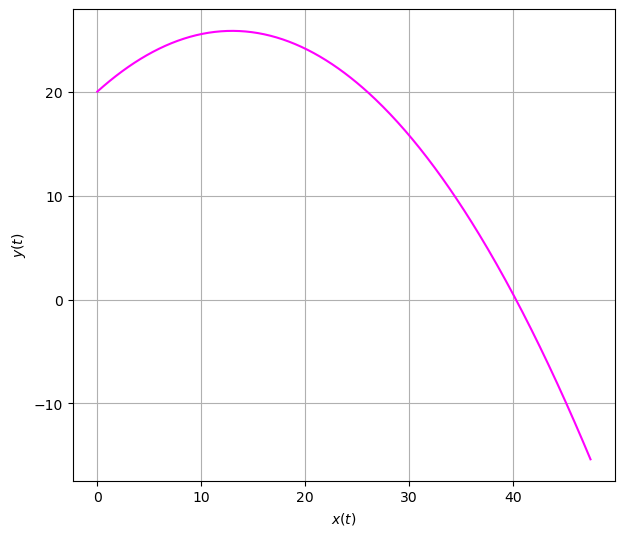

In [6]:
ball_kin.plot_rcomp(figsize=(7,7))

### Rajzoljuk ki a komponenseket az idő függvényében

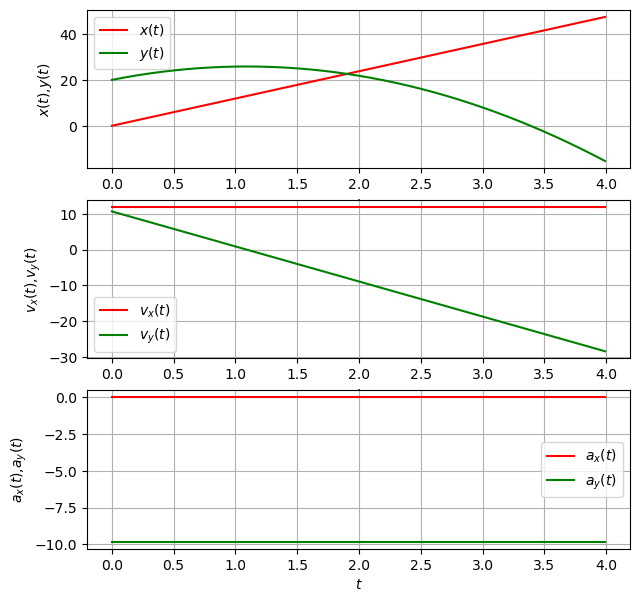

In [7]:
ball_kin.plot_rva_coord(figsize=(7,7))

### Mikor és hol volt a test a legmagasabban?

In [8]:
# Legmagasabb: y koordináta maximális.

y_work=ball_kin.r[:,1] # ez a test y-koordinátája az idő függvényében

arg_ymax=y_work.argmax()

print("A legmagasabb pont:")
print("    ideje:", ball_kin.t[arg_ymax],"s")
print("    helye:", ball_kin.r[arg_ymax],"m")

A legmagasabb pont:
    ideje: 1.09 s
    helye: [12.96044576 25.84200727] m


### Mikor és hol csapódott a földbe?

In [9]:
# földbe csapódás: y=0
# előző y_work felhasználásával

becsap_args=arg_eq(y_work, 0.0)

# Akár több megoldás is lehetne más mozgásnál!

print(f"A test a talajszintet {len(becsap_args)} alkalommal éri el.")
print("Ezek adatai:")
for arg in becsap_args:
    print(f"   idő: {ball_kin.t[arg]:7.2f} s\tx: {ball_kin.r[arg, 0]:7.2f} m\ty: {ball_kin.r[arg,1]:7.2f} m.")

A test a talajszintet 1 alkalommal éri el.
Ezek adatai:
   idő:    3.38 s	x:   40.19 m	y:    0.15 m.


# 2. teszt: Dinamika

In [10]:
# Bemenő adatok: (mint az 1. tesztnél)
h=20.0
v0_abs=16.0
alpha_deg=42.0
g=9.81

# Kezdőértékek koordinátái
v0_x=v0_abs*np.cos(np.radians(alpha_deg))
v0_y=v0_abs*np.sin(np.radians(alpha_deg))

x0=0.0
y0=h

Most jön az újdonság: Nem megadjuk a gyorsulás-idő függvényt, hanem a tömeget és az erőfüggvényt határozzuk meg.


In [11]:
def create_grav_közeg_F_m(m, C, A, rho, g=9.81):
    """Egy konstans tömegű test tömege és a rá ható erő gravitációs tér és közegellenállás jelenlétében."""
    
    
    # konstans tömeg
    def mass_fun(t):   # formai okokból kell a t de ettől nem függ a tömeg ebben az esetben
        return m
    

    def force_fun(t, r, v, m):  # formai okokból kell a t, r, v de egyiktől sem függ ez az erőfüggvény
        """Gravitációs erő y irányban és v^2-tel arányos közegellenállási erő eredője."""
        
        F_work=np.array([0.0, -m*g], np.float64)  # grav erő
        v_abs=((v**2).sum())**0.5
        F_work-=0.5*C*A*rho*v*v_abs # közegell. erő hatása
    
        return F_work

    return force_fun, mass_fun

# függvényekkel kell visszatérni

Továbbá nem fix időpontig megyünk, hanem a leállásnak egyéb feltételt szabunk.

In [12]:
# Ha ez a függvény True-val tér vissza, akkor leáll a szimuláció

def stop_ground_y(r, v):
    """Leállás y<0 esetén"""
    
    return r[1]<0.0

In [13]:
# focilabda dinamikai paraméterei

m_soccer=0.43      # focilabda közepes tömeg
perim_soccer=0.69  # focilabda közepes kerület

r=perim_soccer/(2*np.pi)
A=np.pi*r**2  # mozgásirányú keresztmetszet
C=0.47     # gömb
rho=1.3    # levegő sűrűség
g=9.81

# legeneráljuk az erő és tömegfüggvényeket erre a labdára:
F_soccer, m_soccer = create_grav_közeg_F_m(m_soccer, C, A, rho, g)

In [14]:
# dinamikai szimuláció objektum:
ball_din=num_dinam(2)

# időtartam
ball_din.set_time_range(0.0, 10.0, 0.01)

# erő- és tömegfüggvény: az előző blokkból
ball_din.set_mass_fun(m_soccer)
ball_din.set_F_fun(F_soccer)

# kezdőfeltétel: fentről
ball_din.set_r0_v0([x0, y0], [v0_x, v0_y])

# itt jön a leállási feltétel specifikálása:
ball_din.set_stop_cond(stop_ground_y)   # a fenti függvény megadása

# dinamikai számítások: ez végigszámolja delta_t-nként a mozgást
ball_din.full_dinam_calc()

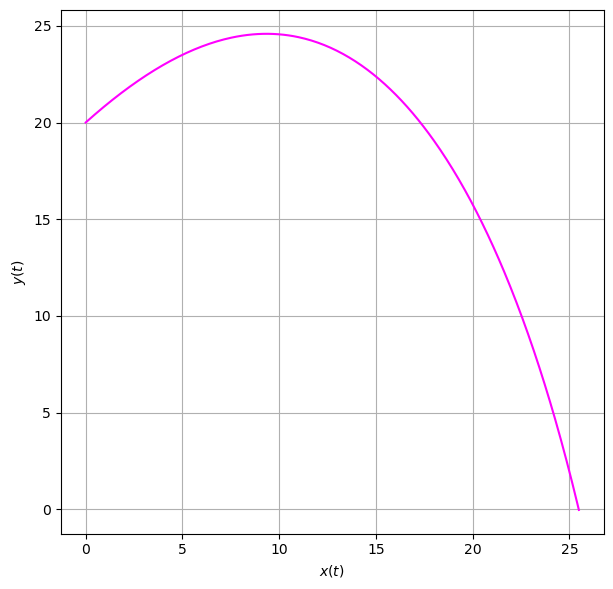

In [15]:
# pályagörbe
ball_din.plot_rcomp(figsize=(7,7))

### Mikor és hol volt a test a legmagasabban?

In [16]:
# Legmagasabb: y koordináta maximális.

y_work=ball_din.r[:,1] # ez a test y-koordinátája az idő függvényében

arg_ymax=y_work.argmax()

print("A legmagasabb pont:")
print("    ideje:", ball_din.t[arg_ymax],"s")
print("    helye:", ball_din.r[arg_ymax],"m")

A legmagasabb pont:
    ideje: 0.9200000000000006 s
    helye: [ 9.34661048 24.58500047] m


### Mikor és hol csapódott a földbe?

In [17]:
# földbe csapódás: y=0
# előző y_work felhasználásával

becsap_args=arg_eq(y_work, 0.0)

# Akár több megoldás is lehetne más mozgásnál!

print(f"A test a talajszintet {len(becsap_args)} alkalommal éri el.")
print("Ezek adatai:")
for arg in becsap_args:
    print(f"   idő: {ball_din.t[arg]:7.2f} s\tx: {ball_din.r[arg, 0]:7.2f} m\ty: {ball_din.r[arg,1]:7.2f} m.")

A test a talajszintet 1 alkalommal éri el.
Ezek adatai:
   idő:    3.46 s	x:   25.45 m	y:    0.14 m.


# 3. teszt: GPS adatok beolvasása, simítása

Csak a biztonság kedvéért teszteljük, ez is rendben van-e.

In [18]:
vonat=GPS_to_num_kinem('Kelenföld-Köki.txt', orig='first')
vonat_sm=num_kinem_smooth_r(vonat, 0.1, lam=30, err_report=True)

Adatsor pontosság: RMS=11.441; MAX=15.000
Eltérés          : RMS=1.635; MAX=8.071


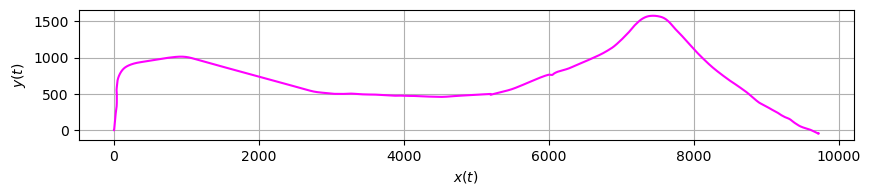

In [19]:
vonat_sm.plot_rcomp(figsize=(10,7))

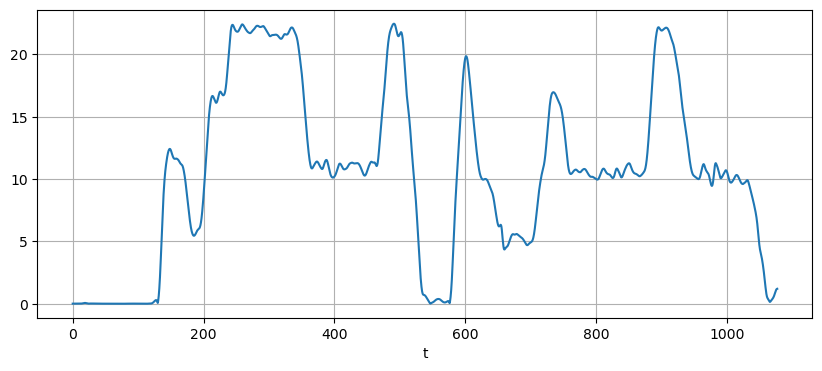

In [20]:
# A vonat sebesség-nagyság-idő függvénye:
vonat_sm.v_abs=vect_abs(vonat_sm.v)

fig=plt.figure(figsize=(10,4))  
ax1=plt.subplot(111)

ax1.plot(vonat_sm.t, vonat_sm.v_abs)
ax1.set_xlabel('t')

ax1.grid()

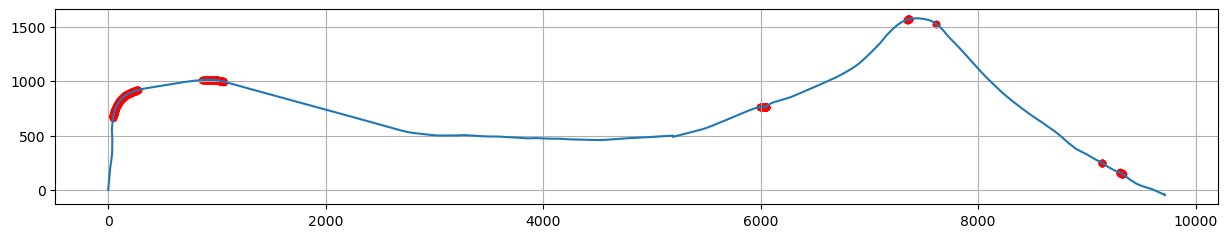

In [21]:
# Éles kanyarodás: a_cp>0.5 m/s^2
map_kanyar=vonat_sm.a_cp>0.5

fig=plt.figure(figsize=(15,8))  
ax1=plt.subplot(111)

ax1.plot(vonat_sm.r[:,0], vonat_sm.r[:,1])
ax1.scatter(vonat_sm.r[map_kanyar,0], vonat_sm.r[map_kanyar,1], color="red", s=20)

ax1.set_aspect(aspect='equal')
ax1.grid()
